# Exploratory Data Analysis (EDA)

## Table of Contents
1. [Dataset Overview](#dataset-overview)
2. [Handling Missing Values](#handling-missing-values)
3. [Feature Distributions](#feature-distributions)
4. [Possible Biases](#possible-biases)
5. [Correlations](#correlations)


. [Correlations](#correlations)


In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Dataset Overview

[Provide a high-level overview of the dataset. This should include the source of the dataset, the number of samples, the number of features, and example showing the structure of the dataset.]


In [3]:
# Load the data
df = pd.read_csv('songs_dataset.csv')

# Number of samples
num_samples = df.shape[0]

# Number of features
num_features = df.shape[1]

# Display these dataset characteristics
print(f"Number of samples: {num_samples}")
print(f"Number of features: {num_features}")

# Display the first few rows of the dataframe to show the structure
print("Example data:")
print(df.head())

Number of samples: 202
Number of features: 21
Example data:
                       id                                               name  \
0  4kbj5MwxO1bq9wjT5g9HaA                                  Shut Up and Dance   
1  7a53HqqArd4b9NF4XAmlbI                                     Kings & Queens   
2  2ygMBIctKIAfbEBcT9065L                                            Pump It   
3  5nEdwtSv0qqeE0l4o1lR4q  (When You Gonna) Give It Up to Me (feat. Keysh...   
4  1rIKgCH4H52lrvDcz50hS8                                          Lush Life   

   popularity  duration_ms  explicit                        artists  \
0          82       199080         0              ['WALK THE MOON']   
1          85       162399         0                    ['Ava Max']   
2          77       213067         0            ['Black Eyed Peas']   
3          59       243880         0  ['Sean Paul', 'Keyshia Cole']   
4          78       201122         0               ['Zara Larsson']   

                                

## Handling Missing Values

[Identify any missing values in the dataset, and describe your approach to handle them if there are any. If there are no missing values simply indicate that there are none.]


In [4]:
# Check for missing values
missing_values = df.isnull().sum()
missing_values


id                  0
name                0
popularity          0
duration_ms         0
explicit            0
artists             0
id_artists          0
release_date        0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
label               0
dtype: int64

In [5]:
# Handling missing values
# Drop rows with missing values 
df = df.dropna()

# Check the number of samples after dropping missing values
print("Number of samples after dropping missing values:", df.shape[0])

Number of samples after dropping missing values: 202


## Feature Distributions

[Plot the distribution of various features and target variables. Comment on the skewness, outliers, or any other observations.]


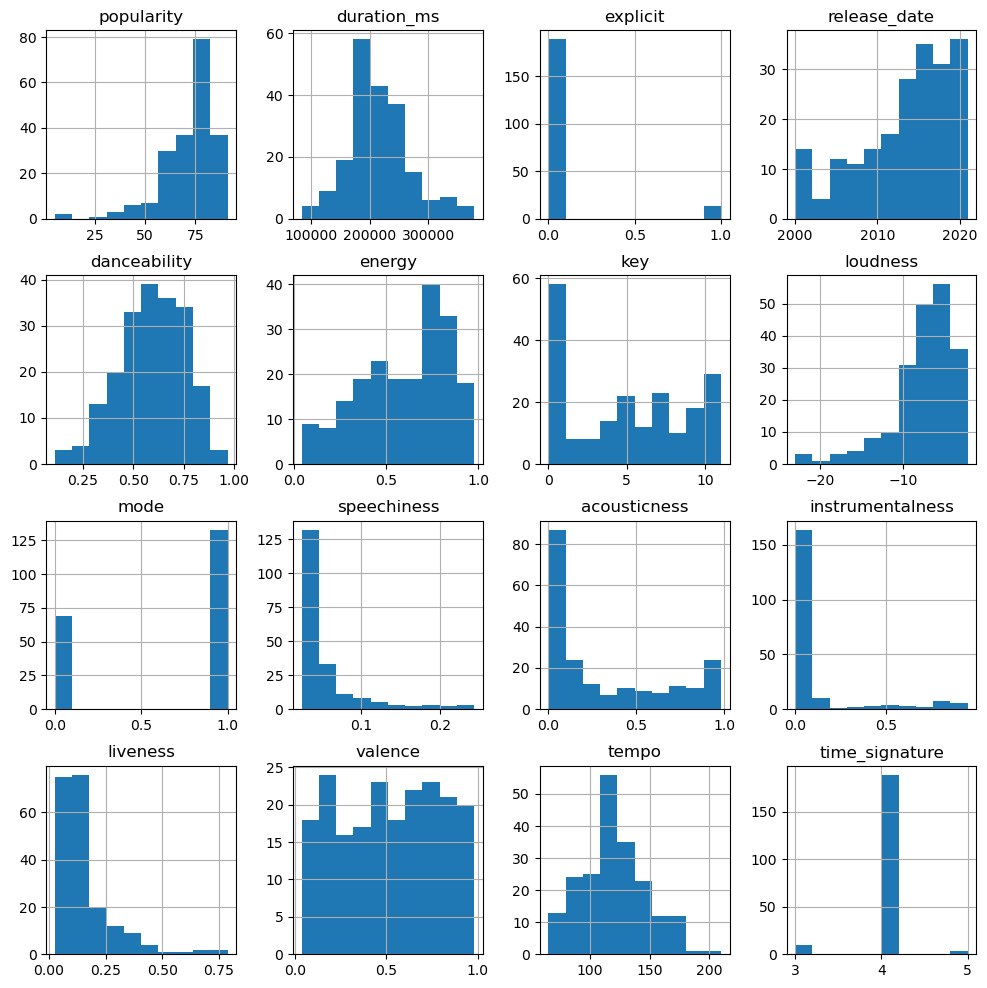

In [6]:
# Example: Plotting histograms of all numerical features
df.hist(figsize=(12, 12))
plt.show()


## Possible Biases

[Investigate the dataset for any biases that could affect the model’s performance and fairness (e.g., class imbalance, historical biases).]


CLASS DISTRIBUTION
label
happy    103
sad       99
Name: count, dtype: int64



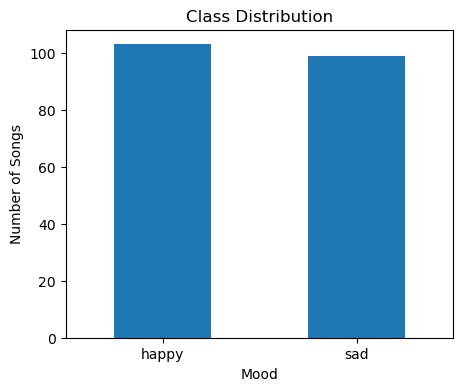

POPULARITY STATISTICS
            mean        std   min   max
label                                  
happy  72.631068  12.687025   5.0  86.0
sad    71.818182  13.640698  13.0  91.0



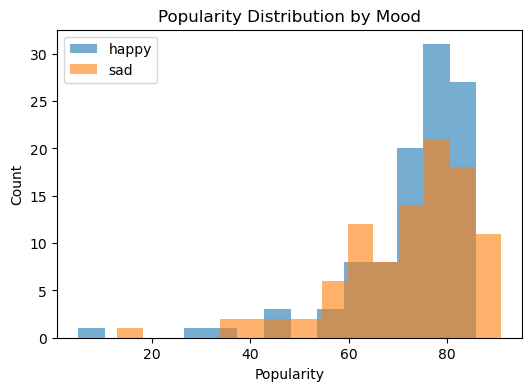

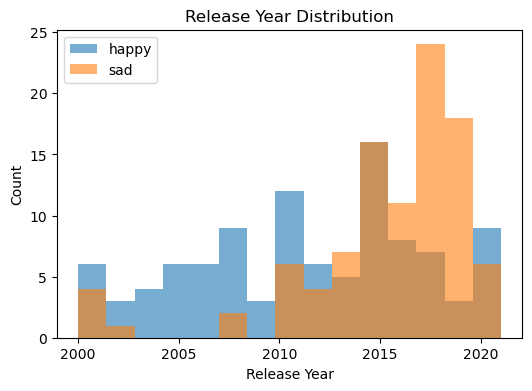

TOP 10 MOST COMMON ARTISTS
artists
['Billie Eilish']      7
['Bruno Mars']         5
['Coldplay']           4
['Harry Styles']       4
['Maroon 5']           3
['Jack Johnson']       3
['Lewis Capaldi']      3
['XXXTENTACION']       3
['Black Eyed Peas']    2
['The Jackson 5']      2
Name: count, dtype: int64



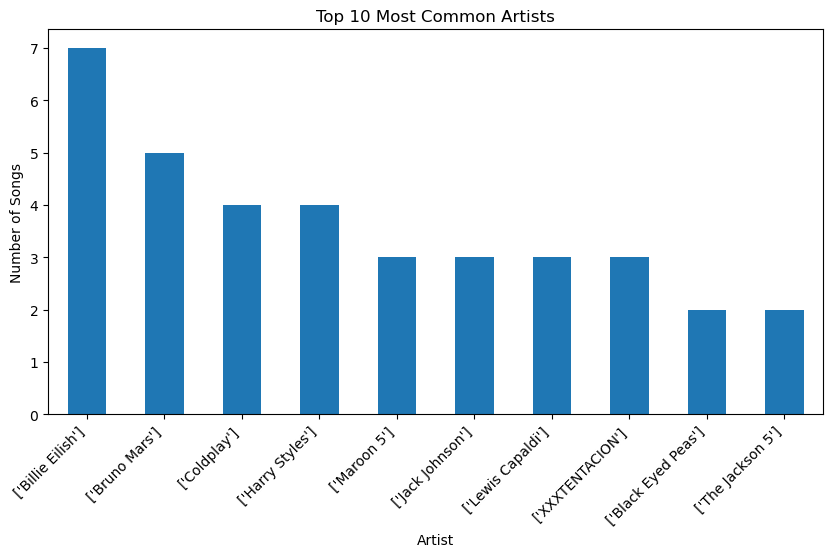

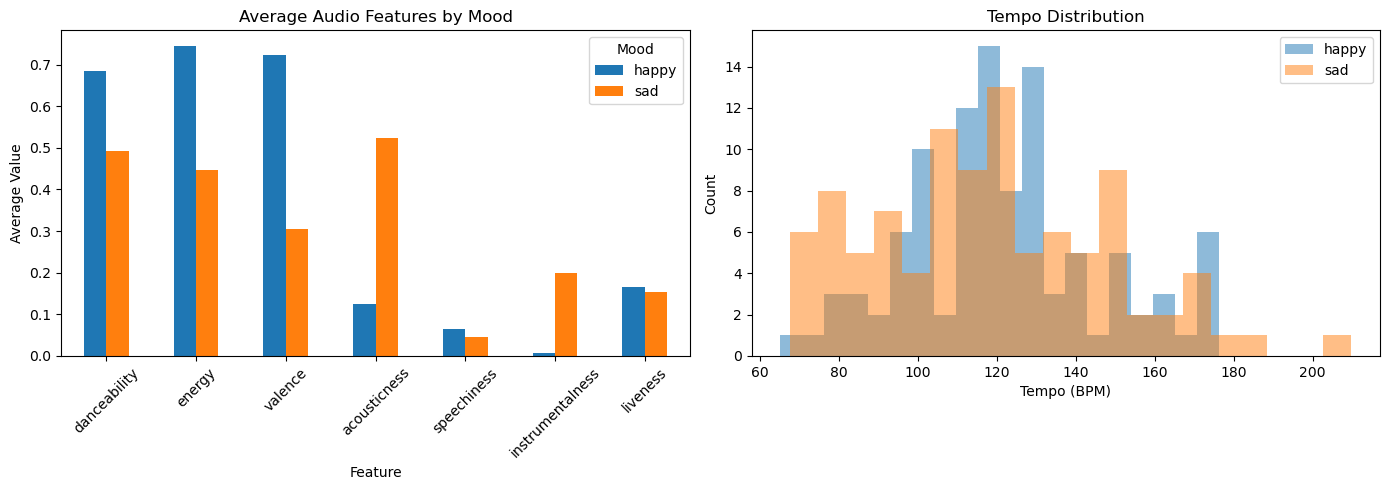

In [27]:
# Class balance bias

print("CLASS DISTRIBUTION")
print(df["label"].value_counts())
print()

class_counts = df["label"].value_counts()

plt.figure(figsize=(5, 4))
class_counts.plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Mood")
plt.ylabel("Number of Songs")
plt.xticks(rotation=0)

plt.show()


# Popularity bias

print("POPULARITY STATISTICS")
print(
    df.groupby("label")["popularity"]
    .describe()[["mean", "std", "min", "max"]]
)
print()

plt.figure(figsize=(6, 4))

for label in df["label"].unique():
    subset = df[df["label"] == label]

    plt.hist(
        subset["popularity"],
        bins=15,
        alpha=0.6,
        label=label
    )

plt.title("Popularity Distribution by Mood")
plt.xlabel("Popularity")
plt.ylabel("Count")
plt.legend()

plt.show()

# Release year bias

plt.figure(figsize=(6, 4))

for label in df["label"].unique():

    subset = df[df["label"] == label]

    plt.hist(
        subset["release_date"],
        bins=15,
        alpha=0.6,
        label=label
    )

plt.title("Release Year Distribution")
plt.xlabel("Release Year")
plt.ylabel("Count")

plt.legend()

plt.show()

# Duplicate artists bias

artist_counts = (
    df["artists"]
    .value_counts()
    .head(10)
)

print("TOP 10 MOST COMMON ARTISTS")
print(artist_counts)
print()

plt.figure(figsize=(10, 5))
artist_counts.plot(kind="bar")

plt.title("Top 10 Most Common Artists")
plt.xlabel("Artist")
plt.ylabel("Number of Songs")
plt.xticks(rotation=45, ha="right")

plt.show()

# Feature distribution bias + tempo subplot

features = [
    "danceability",
    "energy",
    "valence",
    "acousticness",
    "speechiness",
    "instrumentalness",
    "liveness"
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left subplot: feature distributions
feature_means = df.groupby("label")[features].mean()

feature_means.T.plot(
    kind="bar",
    ax=axes[0]
)

axes[0].set_title("Average Audio Features by Mood")
axes[0].set_xlabel("Feature")
axes[0].set_ylabel("Average Value")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend(title="Mood")


# Right subplot: tempo distribution
for label in df["label"].unique():
    subset = df[df["label"] == label]

    axes[1].hist(
        subset["tempo"],
        bins=20,
        alpha=0.5,
        label=label
    )

axes[1].set_title("Tempo Distribution")
axes[1].set_xlabel("Tempo (BPM)")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.show()

## Correlations

[Explore correlations between features and the target variable, as well as among features themselves.]


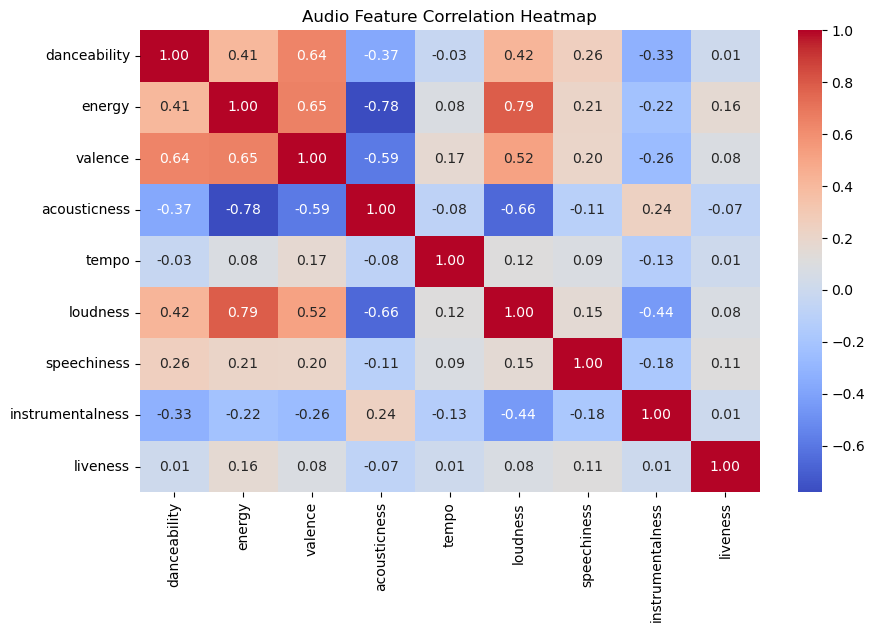

In [28]:
audio_features = [
    "danceability",
    "energy",
    "valence",
    "acousticness",
    "tempo",
    "loudness",
    "speechiness",
    "instrumentalness",
    "liveness"
]

correlation_matrix = df[audio_features].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Audio Feature Correlation Heatmap")
plt.show()
